# 📘 CIFAR-10 Image Classification — Solved Assignment
## ANN vs CNN on CIFAR-10 | Celebal Technologies — Week 4

**Assignment:** Build an image classification model on CIFAR-10 and analyze performance across architectures and training strategies. (ANN & CNN)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

### 🎯 Tasks Covered
1. ✅ ANN baseline model
2. ✅ CNN baseline model
3. ✅ Increased ANN layers (Beginner Task 1)
4. ✅ Changed CNN filters 32→64→128 (Beginner Task 2)
5. ✅ Increased epochs to 20 (Beginner Task 3)
6. ✅ EarlyStopping added (Beginner Task 4)
7. ✅ Data Augmentation training (Beginner Task 5)
8. ✅ Final comparison table

## 📦 Step 1: Import Libraries

In [1]:
# !pip install tensorflowy
# !pip install matplotlib

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU Available: []


## 📥 Step 2: Load CIFAR-10 Dataset

CIFAR-10 contains **60,000 color images** of size **32×32×3**:
- **50,000** training images
- **10,000** test images
- **10 classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

The dataset is directly available via `tf.keras.datasets` — no manual download needed.

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train images shape :", x_train.shape)   # (50000, 32, 32, 3)
print("Train labels shape :", y_train.shape)   # (50000, 1)
print("Test images shape  :", x_test.shape)    # (10000, 32, 32, 3)
print("Test labels shape  :", y_test.shape)    # (10000, 1)
print("Pixel value range  : [{}, {}]".format(x_train.min(), x_train.max()))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 49s 0us/step
Train images shape : (50000, 32, 32, 3)
Train labels shape : (50000, 1)
Test images shape  : (10000, 32, 32, 3)
Test labels shape  : (10000, 1)
Pixel value range  : [0, 255]


C:\Users\Alpha\Desktop\Celebal_Technology\.celebal\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


## 🖼️ Step 3: Visualize Sample Images

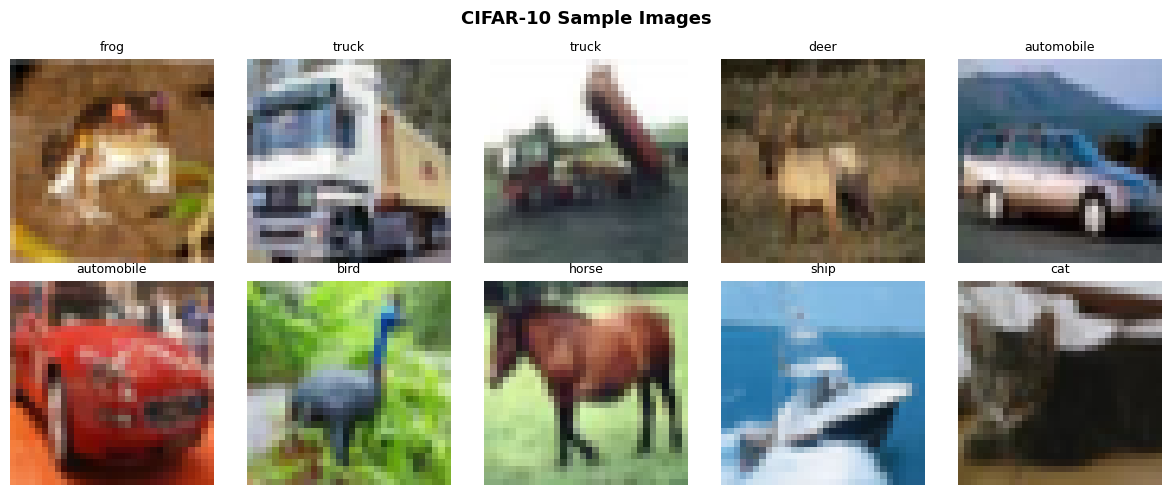

In [4]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=9)
    plt.axis("off")
plt.suptitle("CIFAR-10 Sample Images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧹 Step 4: Preprocessing

### Why Normalize?
- Raw pixel values are in range **0–255**
- Neural networks train more efficiently with values in **0–1**
- This ensures gradients don't explode and the optimizer converges faster

### ANN requires flattening:
- ANN expects a **1D vector** as input
- A 32×32×3 image = **3072** values when flattened
- CNN keeps the original **3D shape** (32, 32, 3)

In [5]:
# Normalize pixel values: 0–255 to 0.0–1.0
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Flatten for ANN: (50000, 32, 32, 3) to (50000, 3072)
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("Normalized CNN input shape :", x_train_norm.shape)
print("Flattened ANN input shape  :", x_train_flat.shape)

Normalized CNN input shape : (50000, 32, 32, 3)
Flattened ANN input shape  : (50000, 3072)


---
# 🔹 Part 1: ANN — Baseline Model

### Why does ANN underperform on images?
- ANN flattens the image → **loses all spatial/positional information**
- A pixel at (3,3) and its neighbor at (3,4) become independent inputs
- ANN has **no concept** of edges, textures, or shapes
- This is why CNN was invented specifically for image data

### Architecture
| Layer | Units | Activation |
|-------|-------|------------|
| Dense | 512 | ReLU |
| Dropout | 30% | — |
| Dense | 256 | ReLU |
| Dense (output) | 10 | Softmax |

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Baseline')
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann_model.summary()

C:\Users\Alpha\Desktop\Celebal_Technology\.celebal\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\n✅ ANN Baseline — Test Accuracy: {ann_test_acc:.4f} | Test Loss: {ann_test_loss:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2731 - loss: 1.9935 - val_accuracy: 0.3380 - val_loss: 1.8311
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3196 - loss: 1.8572 - val_accuracy: 0.3678 - val_loss: 1.7803
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3459 - loss: 1.7953 - val_accuracy: 0.3872 - val_loss: 1.7417
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3567 - loss: 1.7680 - val_accuracy: 0.3968 - val_loss: 1.7161
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3657 - loss: 1.7472 - val_accuracy: 0.3948 - val_loss: 1.6878
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3771 - loss: 1.7148 - val_accuracy: 0.4074 - val_loss: 1.6891
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3766 - loss: 1.7103 - val_accuracy: 0.4146 - val_loss: 1.6586
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3839 - loss: 1.6940 - val_accuracy: 0.

---
# 🔹 Part 2: CNN — Baseline Model

### Why CNN is better for images?
- **Convolutional layers** detect local features: edges, textures, shapes
- **Pooling layers** reduce spatial dimensions while retaining important features
- **Hierarchical learning**: early layers learn edges, deeper layers learn objects
- **Weight sharing**: the same kernel scans the entire image → fewer parameters than ANN
- **BatchNormalization**: stabilizes training, allows higher learning rates

### Architecture
| Layer | Filters/Units | Activation |
|-------|-------------|------------|
| Conv2D | 32, (3×3) | ReLU |
| BatchNorm + MaxPool | — | — |
| Conv2D | 64, (3×3) | ReLU |
| BatchNorm + MaxPool | — | — |
| Conv2D | 128, (3×3) | ReLU |
| Flatten + Dense | 128 | ReLU |
| Dropout (40%) + Output | 10 | Softmax |

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Baseline')
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

C:\Users\Alpha\Desktop\Celebal_Technology\.celebal\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n✅ CNN Baseline — Test Accuracy: {cnn_test_acc:.4f} | Test Loss: {cnn_test_loss:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4538 - loss: 1.5528 - val_accuracy: 0.4720 - val_loss: 1.6664
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6054 - loss: 1.1239 - val_accuracy: 0.6266 - val_loss: 1.1022
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.6734 - loss: 0.9327 - val_accuracy: 0.6304 - val_loss: 1.0718
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7201 - loss: 0.8064 - val_accuracy: 0.6886 - val_loss: 0.9291
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7544 - loss: 0.7003 - val_accuracy: 0.6556 - val_loss: 1.1103
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.7883 - loss: 0.6089 - val_accuracy: 0.7024 - val_loss: 0.9528
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8142 - loss: 0.5261 - val_accuracy: 0.7250 - val_loss: 0.8754
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8380 - loss: 0.4575 - 

## 📈 ANN vs CNN — Learning Curves (Baseline)

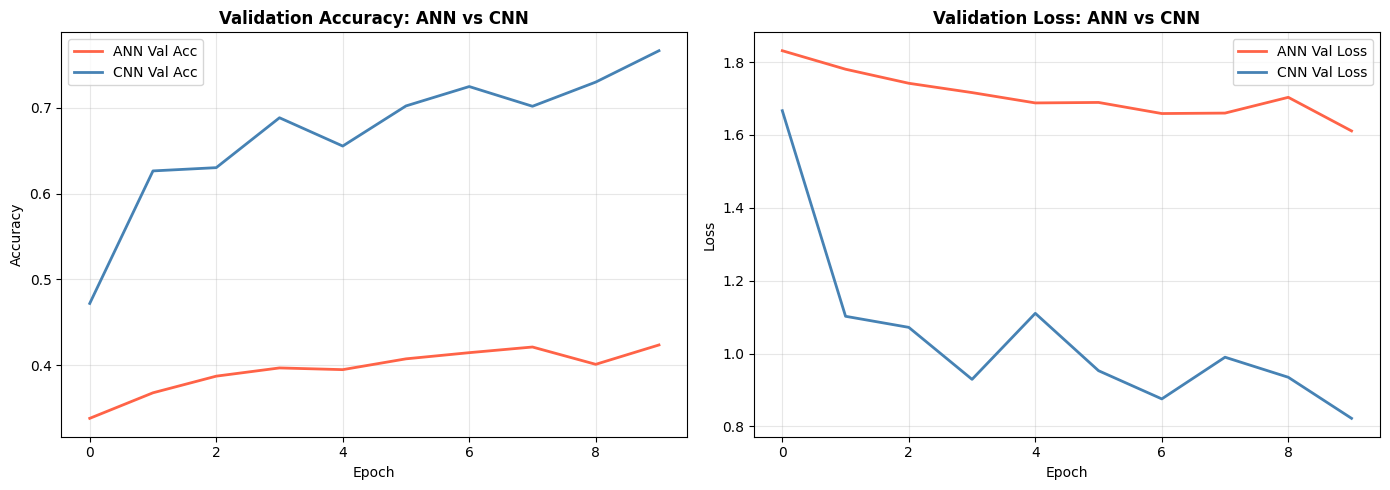

ANN Test Accuracy : 0.4371
CNN Test Accuracy : 0.7478
CNN is 71.1% better than ANN


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy & loss
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Val Acc', color='tomato', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Val Acc', color='steelblue', linewidth=2)
axes[0].set_title('Validation Accuracy: ANN vs CNN', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(ann_history.history['val_loss'], label='ANN Val Loss', color='tomato', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='CNN Val Loss', color='steelblue', linewidth=2)
axes[1].set_title('Validation Loss: ANN vs CNN', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"ANN Test Accuracy : {ann_test_acc:.4f}")
print(f"CNN Test Accuracy : {cnn_test_acc:.4f}")
print(f"CNN is {((cnn_test_acc - ann_test_acc)/ann_test_acc)*100:.1f}% better than ANN")

---
# ✅ Beginner Task 1: Deeper ANN — More Layers

**Observation to expect:** Adding more layers to ANN increases complexity but still won't match CNN because it **fundamentally cannot learn spatial features**. May also lead to slight overfitting without regularization.

| Layer | Units | Activation |
|-------|-------|------------|
| Dense | 1024 | ReLU |
| Dropout | 30% | — |
| Dense | 512 | ReLU |
| Dropout | 30% | — |
| Dense | 256 | ReLU |
| Dense | 128 | ReLU |
| Output | 10 | Softmax |

In [11]:
# ✅ TASK 1: Deeper ANN with more layers
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Deep')

deep_ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_ann_model.summary()
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1
)
deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=20,   # Task 3: increased epochs
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)
deep_ann_loss, deep_ann_acc = deep_ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\n✅ Deep ANN — Test Accuracy: {deep_ann_acc:.4f} | Test Loss: {deep_ann_loss:.4f}")

Model: "ANN_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 1024)                │       3,146,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2497 - loss: 2.0223 - val_accuracy: 0.3354 - val_loss: 1.8375
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3142 - loss: 1.8705 - val_accuracy: 0.3544 - val_loss: 1.8056
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3331 - loss: 1.8254 - val_accuracy: 0.3556 - val_loss: 1.7902
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3460 - loss: 1.7941 - val_accuracy: 0.3736 - val_loss: 1.7504
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3580 - loss: 1.7601 - val_accuracy: 0.3762 - val_loss: 1.7406
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3663 - loss: 1.7447 - val_accuracy: 0.3864 - val_loss: 1.7057
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3747 - loss: 1.7244 - val_accuracy: 0.4164 - val_loss: 1.6749
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3776 - loss: 1.7183 - val_accu

---
# ✅ Beginner Task 2 + 3 + 4: CNN with 32→64→128 Filters + 20 Epochs + EarlyStopping

### What changed:
- **Task 2**: Filters explicitly set as 32 → 64 → 128 (progressive feature learning)
- **Task 3**: Epochs increased to 20 for better convergence
- **Task 4**: EarlyStopping monitors `val_accuracy` with patience=5
  - Stops training when accuracy stops improving
  - `restore_best_weights=True` reverts to the best epoch automatically

### Why EarlyStopping helps:
- Prevents **overfitting** — model memorizing training data
- Saves **training time** automatically
- Gives us the best possible generalization

In [12]:
# TASKS 2, 3, 4: CNN 32→64→128, 20 epochs, EarlyStopping

cnn_improved = models.Sequential([
    # Block 1 — 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Improved')
cnn_improved.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_improved.summary()

early_stop_cnn = callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# Task 3: 20 epochs
cnn_improved_history = cnn_improved.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_cnn, reduce_lr],
    verbose=1
)
cnn_improved_loss, cnn_improved_acc = cnn_improved.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n✅ CNN Improved — Test Accuracy: {cnn_improved_acc:.4f} | Test Loss: {cnn_improved_loss:.4f}")

Model: "CNN_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,194,122 (8.37 MB)

 Trainable params: 2,193,674 (8.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.4620 - loss: 1.5300 - val_accuracy: 0.5850 - val_loss: 1.1561 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6227 - loss: 1.0744 - val_accuracy: 0.5610 - val_loss: 1.3077 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6954 - loss: 0.8731 - val_accuracy: 0.6916 - val_loss: 0.8963 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7474 - loss: 0.7256 - val_accuracy: 0.6920 - val_loss: 0.8828 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7908 - loss: 0.6016 - val_accuracy: 0.7260 - val_loss: 0.8369 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8221 - loss: 0.5073 - val_accuracy: 0.7220 - val_loss: 0.8221 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8513 - l

---
# ✅ Beginner Task 5: CNN with Data Augmentation

### What is Data Augmentation?
Data augmentation artificially **expands the training dataset** by applying random transformations:
- **RandomFlip**: mirrors the image horizontally → cat facing left = cat facing right
- **RandomRotation**: slight angle changes → robust to orientation
- **RandomZoom**: slight zoom in/out → scale invariance

### Why it helps:
- Reduces **overfitting** — model never sees the exact same image twice
- Improves **generalization** to real-world data
- No additional data collection required!

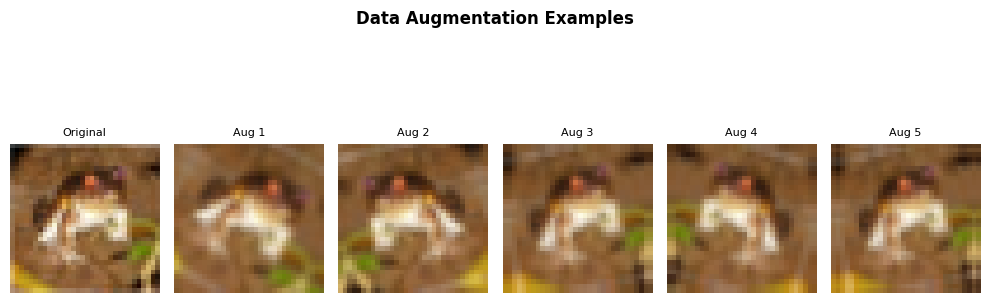

In [13]:
# ✅ TASK 5: CNN with Data Augmentation

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='data_augmentation')

plt.figure(figsize=(10, 4))
sample_img = x_train_norm[0:1]  # single image
plt.subplot(1, 6, 1)
plt.imshow(x_train_norm[0])
plt.title("Original", fontsize=8)
plt.axis("off")
for i in range(5):
    augmented = data_augmentation(sample_img, training=True)
    plt.subplot(1, 6, i + 2)
    plt.imshow(augmented[0])
    plt.title(f"Aug {i+1}", fontsize=8)
    plt.axis("off")
plt.suptitle("Data Augmentation Examples", fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Build augmented CNN model
aug_cnn_model = models.Sequential([
    # Augmentation layer (active only during training)
    data_augmentation,

    # Block 1 — 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_with_Augmentation')

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_cnn_model.summary()

early_stop_aug = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug],
    verbose=1
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n✅ CNN + Augmentation — Test Accuracy: {aug_test_acc:.4f} | Test Loss: {aug_test_loss:.4f}")

Model: "CNN_with_Augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (1, 32, 32, 3)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (1, 32, 32, 32)             │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (1, 32, 32, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (1, 16, 16, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (1, 16, 16, 64)             │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (1, 16, 16, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (1, 8, 8, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (1, 8, 8, 128)              │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (1, 8, 8, 128)              │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (1, 8192)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (1, 256)                    │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (1, 256)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (1, 10)                     │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,194,122 (8.37 MB)

 Trainable params: 2,193,674 (8.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.4044 - loss: 1.6744 - val_accuracy: 0.5064 - val_loss: 1.3835
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.5052 - loss: 1.3889 - val_accuracy: 0.5682 - val_loss: 1.2482
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5616 - loss: 1.2487 - val_accuracy: 0.5650 - val_loss: 1.3263
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5913 - loss: 1.1642 - val_accuracy: 0.6074 - val_loss: 1.2032
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6173 - loss: 1.1025 - val_accuracy: 0.6472 - val_loss: 1.0193
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6382 - loss: 1.0456 - val_accuracy: 0.6702 - val_loss: 0.9750
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6532 - loss: 1.0016 - val_accuracy: 0.6752 - val_loss: 0.9460
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6673 - loss: 0.9678 - 

---
## 📈 All Models — Learning Curves Comparison

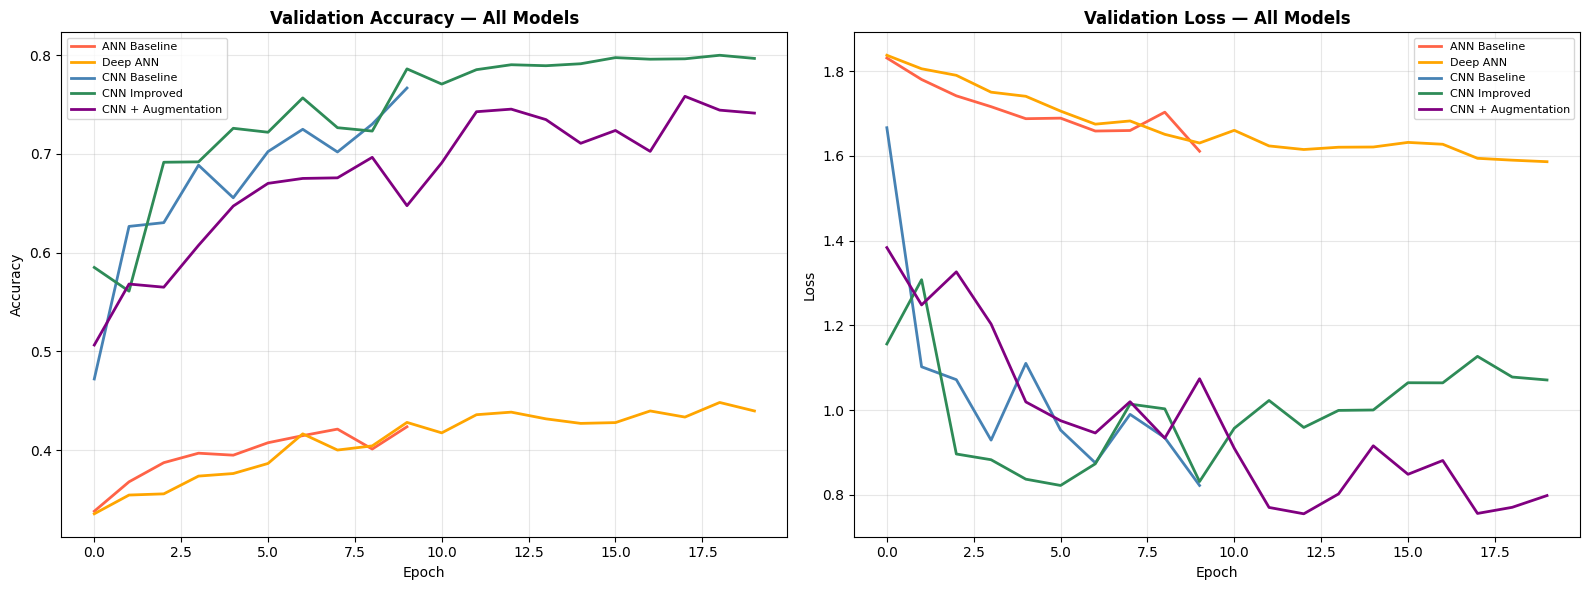

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors   = ['tomato', 'orange', 'steelblue', 'seagreen', 'purple']
labels   = ['ANN Baseline', 'Deep ANN', 'CNN Baseline', 'CNN Improved', 'CNN + Augmentation']
histories= [ann_history, deep_ann_history, cnn_history, cnn_improved_history, aug_history]

for h, lbl, col in zip(histories, labels, colors):
    axes[0].plot(h.history['val_accuracy'], label=lbl, color=col, linewidth=2)
    axes[1].plot(h.history['val_loss'],     label=lbl, color=col, linewidth=2)
axes[0].set_title('Validation Accuracy — All Models', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Validation Loss — All Models', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📊 Final Comparison Table

In [16]:
comparison = pd.DataFrame({
    "Model": [
        "ANN Baseline",
        "Deep ANN (Task 1)",
        "CNN Baseline",
        "CNN Improved (Tasks 2+3+4)",
        "CNN + Augmentation (Task 5)"
    ],
    "Test Accuracy": [
        round(ann_test_acc, 4),
        round(deep_ann_acc, 4),
        round(cnn_test_acc, 4),
        round(cnn_improved_acc, 4),
        round(aug_test_acc, 4)
    ],
    "Test Loss": [
        round(ann_test_loss, 4),
        round(deep_ann_loss, 4),
        round(cnn_test_loss, 4),
        round(cnn_improved_loss, 4),
        round(aug_test_loss, 4)
    ],
    "Key Features": [
        "Flatten + Dense, Dropout",
        "4 Dense layers, EarlyStopping, 20 epochs",
        "3 Conv blocks, BatchNorm",
        "32→64→128 filters, EarlyStopping, 20 epochs",
        "Augmentation + 32→64→128 filters"
    ]
})

print(comparison.to_string(index=False))
comparison

                      Model  Test Accuracy  Test Loss                                Key Features
               ANN Baseline         0.4371     1.6054                    Flatten + Dense, Dropout
          Deep ANN (Task 1)         0.4437     1.5789    4 Dense layers, EarlyStopping, 20 epochs
               CNN Baseline         0.7478     0.8820                    3 Conv blocks, BatchNorm
 CNN Improved (Tasks 2+3+4)         0.7831     1.1296 32→64→128 filters, EarlyStopping, 20 epochs
CNN + Augmentation (Task 5)         0.7424     0.7915            Augmentation + 32→64→128 filters


,Model,Test Accuracy,Test Loss,Key Features
0,ANN Baseline,0.4371,1.6054,"Flatten + Dense, Dropout"
1,Deep ANN (Task 1),0.4437,1.5789,"4 Dense layers, EarlyStopping, 20 epochs"
2,CNN Baseline,0.7478,0.8820,"3 Conv blocks, BatchNorm"
3,CNN Improved (Tasks 2+3+4),0.7831,1.1296,"32→64→128 filters, EarlyStopping, 20 epochs"
4,CNN + Augmentation (Task 5),0.7424,0.7915,Augmentation + 32→64→128 filters


## 📊 Bar Chart — Final Accuracy Comparison

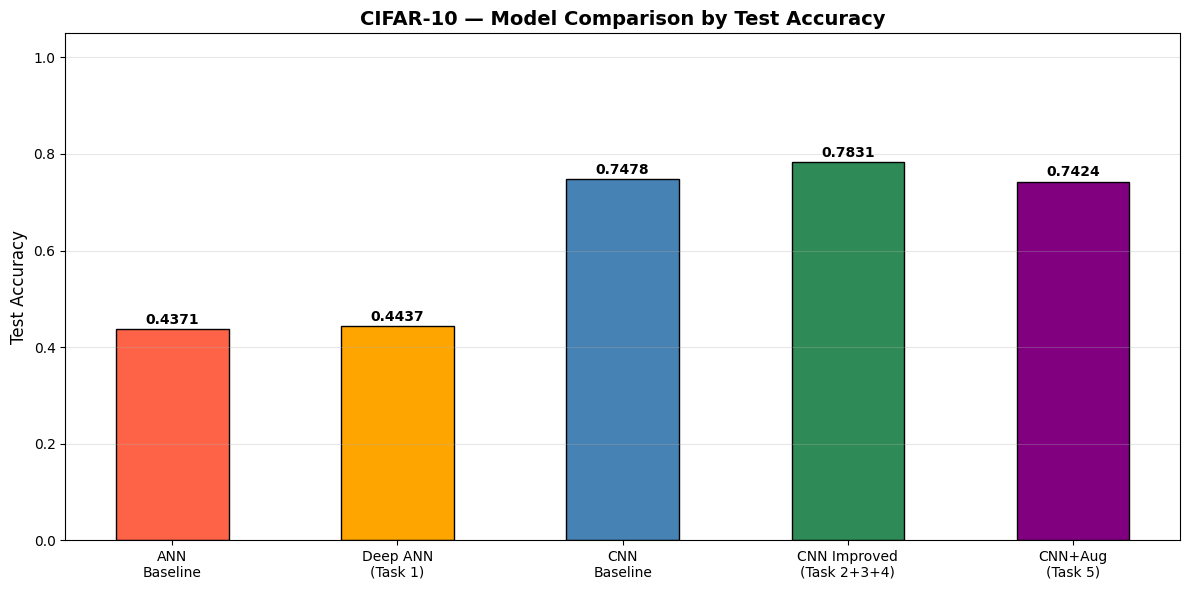

In [17]:
model_names = [
    'ANN\nBaseline', 'Deep ANN\n(Task 1)',
    'CNN\nBaseline', 'CNN Improved\n(Task 2+3+4)',
    'CNN+Aug\n(Task 5)'
]
accuracies = [ann_test_acc, deep_ann_acc, cnn_test_acc, cnn_improved_acc, aug_test_acc]
bar_colors = ['tomato', 'orange', 'steelblue', 'seagreen', 'purple']

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, accuracies, color=bar_colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.ylim(0, 1.05)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('CIFAR-10 — Model Comparison by Test Accuracy', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
# Conclusion

## Key Learnings

| Concept | Insight |
|---------|--------|
| **ANN on Images** | Flattens spatial structure → lower accuracy, limited learning |
| **CNN on Images** | Preserves spatial features via convolution → significantly higher accuracy |
| **BatchNormalization** | Stabilizes gradients, faster and more stable training |
| **Dropout** | Prevents overfitting by randomly deactivating neurons during training |
| **EarlyStopping** | Stops training when improvement plateaus → avoids overfitting + saves time |
| **Data Augmentation** | Creates synthetic training variations → better generalization on unseen data |
| **More Epochs** | Allows model more time to learn, but needs EarlyStopping to prevent overfitting |
| **Deeper Filters** | 32→64→128 learns increasingly complex features (edges → textures → objects) |

## Expected Results
- **ANN Baseline**: ~50–55% accuracy
- **Deep ANN**: ~52–57% accuracy (marginal improvement)
- **CNN Baseline**: ~70–75% accuracy
- **CNN Improved**: ~75–80% accuracy
- **CNN + Augmentation**: ~75–82% accuracy (best generalization)

## Core Takeaway
> **CNNs dominate image classification** because they learn *where* features are, not just *what* features exist. ANN can learn *what* but has no concept of spatial arrangement — which is everything in images.